# Rescale a Grid Solver Geometry File
* Contributor: Martin Diehl (https://martin-diehl.net) and Philip Eisenlohr (eisenlohr@egr.msu.edu)
* DAMASK version: 3.1.0
* Prerequisites (data): Grid file
* Prerequisites (Python): [pyvista](https://pypi.org/project/pyvista/)


In [1]:
import damask
import numpy as np
import pyvista as pv

pv.set_jupyter_backend('static')

In [2]:
# adjust to your situation, input file needs to exist
cells = [20,20,20]

file_name_in  = 'rescale_grid/20grains64x64x64.vti'
file_name_out = f'20grains{"x".join(map(str,cells))}.vti'


In [3]:
grid = damask.GeomGrid.load(file_name_in)
scaled = grid.scale(cells)
scaled.save(file_name_out)

print(f'original grid:\n{grid}\n')
print(f'scaled grid:\n{scaled}\n')


original grid:
cells:  64 × 64 × 64
size:   1.0 × 1.0 × 1.0 m³
origin: 0.0   0.0   0.0 m
# materials: 20

scaled grid:
cells:  20 × 20 × 20
size:   1.0 × 1.0 × 1.0 m³
origin: 0.0   0.0   0.0 m
# materials: 20



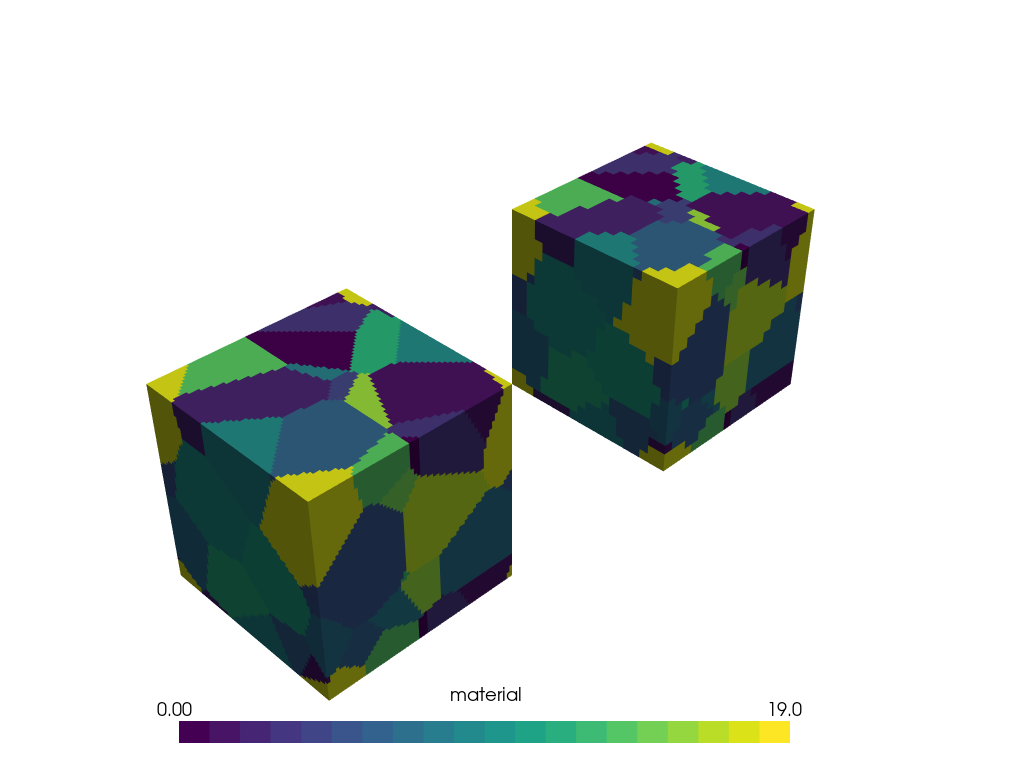

In [4]:
org = pv.ImageData(dimensions=grid.cells+1,
                   spacing=grid.size/grid.cells,
                   origin=grid.origin)
scl = pv.ImageData(dimensions=scaled.cells+1,
                   spacing=scaled.size/scaled.cells,
                   origin=scaled.origin+np.array([-2,0,0]))
org['material'] =   grid.material.flatten('F')
scl['material'] = scaled.material.flatten('F')

pl = pv.Plotter()
pl.set_background('white')
pl.add_mesh(org,
            n_colors = grid.N_materials,
            scalar_bar_args = {
                'title'      : 'material',
                'n_labels'   : 2,
                'position_x' : 0.175,
                'position_y' : 0.03125,
            }
           )
pl.add_mesh(scl,
            show_scalar_bar = False)
pl.show()